# Exercise 1: Basic Usage of SciPy


In [5]:
import scipy
print("SciPy version:", scipy.__version__)

# You can also explore sub-modules
import scipy.stats
import scipy.optimize
print("scipy.stats available:", dir(scipy.stats)[:5])

SciPy version: 1.17.1
scipy.stats available: ['Binomial', 'BootstrapMethod', 'CensoredData', 'ConstantInputWarning', 'Covariance']


# Exercise 2: Descriptive Statistics

In [6]:
from scipy import stats
import numpy as np

data = [12, 15, 13, 12, 18, 20, 22, 21]

mean     = np.mean(data)          # 16.625
median   = np.median(data)        # 16.5
variance = np.var(data, ddof=1)   # sample variance (ddof=1)
std_dev  = np.std(data, ddof=1)   # sample std deviation

print(f"Mean:     {mean:.3f}")
print(f"Median:   {median:.3f}")
print(f"Variance: {variance:.3f}")
print(f"Std Dev:  {std_dev:.3f}")

# scipy.stats.describe gives a compact summary
desc = stats.describe(data)
print("\nscipy describe:", desc)

Mean:     16.625
Median:   16.500
Variance: 17.125
Std Dev:  4.138

scipy describe: DescribeResult(nobs=np.int64(8), minmax=(np.int64(12), np.int64(22)), mean=np.float64(16.625), variance=np.float64(17.125), skewness=np.float64(0.06525681329773589), kurtosis=np.float64(-1.6476734867850917))


# Exercise 3: Understanding Distributions

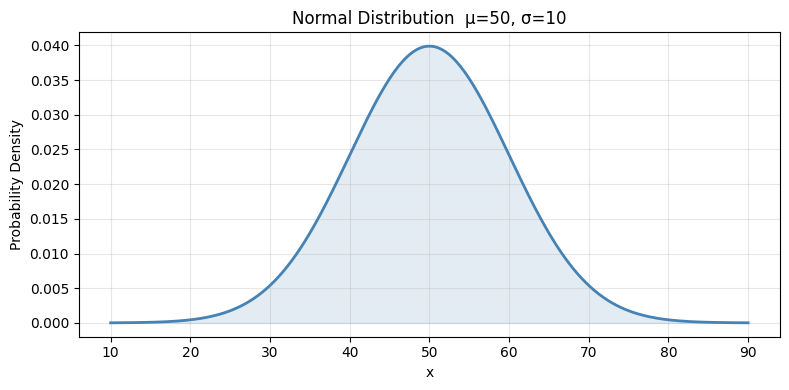

P(X ≤ 60) = 0.8413


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 50, 10

x   = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, color='steelblue', linewidth=2)
plt.fill_between(x, pdf, alpha=0.15, color='steelblue')
plt.title(f'Normal Distribution  μ={mu}, σ={sigma}')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# CDF: probability that X ≤ 60
prob = norm.cdf(60, loc=mu, scale=sigma)
print(f"P(X ≤ 60) = {prob:.4f}")

# Exercise 4: T-Test Application

In [8]:
import numpy as np
from scipy import stats

np.random.seed(42)
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

t_stat, p_value = stats.ttest_ind(data1, data2)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"p={p_value:.4f} < {alpha} → Reject H₀")
    print("The two groups have significantly different means.")
else:
    print(f"p={p_value:.4f} ≥ {alpha} → Fail to reject H₀")
    print("No significant difference between groups.")

T-statistic: -8.5515
P-value:     0.000000

p=0.0000 < 0.05 → Reject H₀
The two groups have significantly different means.


# Exercise 5: Linear Regression Analysis

Slope:     1828.77 currency units / m²
Intercept: 64383.56
R²:        0.9884

Predicted price for 90 m²: 228,973


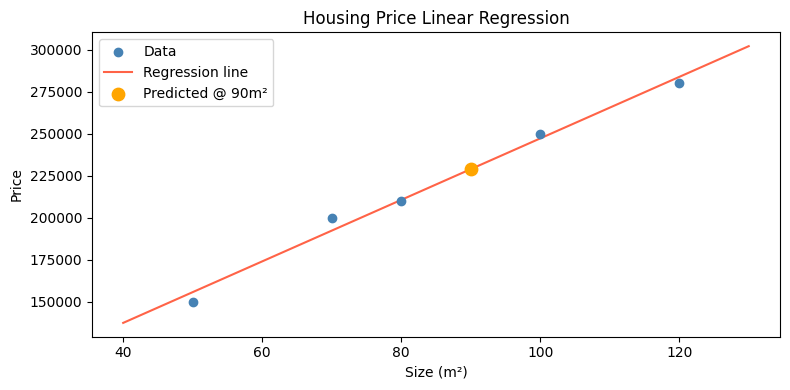

In [9]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

house_sizes  = [50, 70, 80, 100, 120]
house_prices = [150_000, 200_000, 210_000, 250_000, 280_000]

slope, intercept, r_value, p_value, std_err = stats.linregress(
    house_sizes, house_prices
)

print(f"Slope:     {slope:.2f} currency units / m²")
print(f"Intercept: {intercept:.2f}")
print(f"R²:        {r_value**2:.4f}")

# Predict price for 90 m²
size_to_predict = 90
predicted_price = slope * size_to_predict + intercept
print(f"\nPredicted price for {size_to_predict} m²: {predicted_price:,.0f}")

# Plot
x_line = np.linspace(40, 130, 200)
plt.figure(figsize=(8, 4))
plt.scatter(house_sizes, house_prices, color='steelblue', zorder=5, label='Data')
plt.plot(x_line, slope * x_line + intercept, color='tomato', label='Regression line')
plt.scatter([size_to_predict], [predicted_price],
            color='orange', s=80, zorder=6, label=f'Predicted @ {size_to_predict}m²')
plt.xlabel('Size (m²)')
plt.ylabel('Price')
plt.title('Housing Price Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

# Exercise 6: Understanding ANOVA

In [10]:
from scipy import stats

fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

f_value, p_value = stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)

print(f"F-value: {f_value:.4f}")
print(f"P-value: {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"p < {alpha} → Reject H₀")
    print("At least one fertilizer produces significantly different growth.")
else:
    print(f"p ≥ {alpha} → Fail to reject H₀")
    print("No significant difference between fertilizer groups.")

# If p > 0.05:
print("\nIf p > 0.05:")
print("We cannot conclude the fertilizers differ. Any observed")
print("differences are likely due to random chance (sampling noise).")

F-value: 28.5263
P-value: 0.000028

p < 0.05 → Reject H₀
At least one fertilizer produces significantly different growth.

If p > 0.05:
We cannot conclude the fertilizers differ. Any observed
differences are likely due to random chance (sampling noise).


# Exercise 7: Probability Distributions (Optional)

P(X = 5) = 0.2461
P(X ≤ 5) = 0.6230


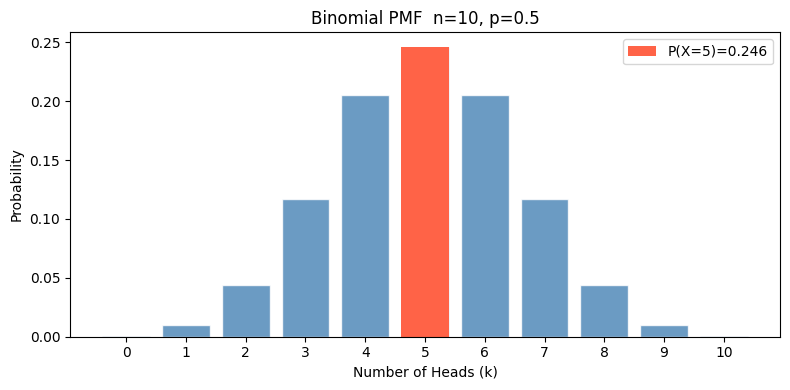

In [12]:
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt

n = 10    # number of trials (coin flips)
p = 0.5   # probability of success (heads)

# P(exactly 5 heads)
prob_5 = binom.pmf(k=5, n=n, p=p)
print(f"P(X = 5) = {prob_5:.4f}")

# P(at most 5 heads)
prob_le5 = binom.cdf(k=5, n=n, p=p)
print(f"P(X ≤ 5) = {prob_le5:.4f}")

# Full PMF plot
k_vals = np.arange(0, n + 1)
pmf_vals = binom.pmf(k_vals, n, p)

plt.figure(figsize=(8, 4))
plt.bar(k_vals, pmf_vals, color='steelblue', alpha=0.8, edgecolor='white')
plt.bar([5], [prob_5], color='tomato', label=f'P(X=5)={prob_5:.3f}')
plt.xlabel('Number of Heads (k)')
plt.ylabel('Probability')
plt.title(f'Binomial PMF  n={n}, p={p}')
plt.xticks(k_vals)
plt.legend()
plt.tight_layout()
plt.show()

# Exercise 8: Correlation Coefficients (Optional)

In [11]:
import pandas as pd
from scipy import stats

data = pd.DataFrame({
    'age':    [23, 25, 30, 35, 40],
    'income': [35_000, 40_000, 50_000, 60_000, 70_000]
})

# Pearson — measures LINEAR correlation
pearson_r, pearson_p = stats.pearsonr(data['age'], data['income'])

# Spearman — measures RANK (monotonic) correlation, robust to outliers
spearman_r, spearman_p = stats.spearmanr(data['age'], data['income'])

print(f"Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.4f})")
print(f"Spearman r = {spearman_r:.4f}  (p = {spearman_p:.4f})")
print()
print("Interpretation:")
print("Both ≈ 1.0 → strong positive correlation between age and income.")
print("Pearson assumes linearity; Spearman does not.")

Pearson  r = 0.9997  (p = 0.0000)
Spearman r = 1.0000  (p = 0.0000)

Interpretation:
Both ≈ 1.0 → strong positive correlation between age and income.
Pearson assumes linearity; Spearman does not.
